In [1]:
# Section 1 — Imports and Load Pickled Files

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project paths (same as Notebook 01)
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
CHECKPOINTS_DIR.mkdir(exist_ok=True)

X_TRAIN_PICKLE = DATA_DIR / 'x_train.pkl'
X_TEST_PICKLE = DATA_DIR / 'x_test.pkl'
PARENT_PAIRS_PICKLE = DATA_DIR / 'parent_pairs.pkl'

# Device — explicitly check, expecting CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version:  {torch.__version__}")
print(f"Device:           {DEVICE}")
print(f"Random seed:      {SEED}")

# Load the three pickled files
print("\n" + "=" * 70)
print("LOADING PICKLED FILES")
print("=" * 70)

x_train_df = pd.read_pickle(X_TRAIN_PICKLE)
x_test_df = pd.read_pickle(X_TEST_PICKLE)
parent_pairs_df = pd.read_pickle(PARENT_PAIRS_PICKLE)

print(f"\nx_train.pkl:        {x_train_df.shape}")
print(f"x_test.pkl:         {x_test_df.shape}")
print(f"parent_pairs.pkl:   {parent_pairs_df.shape}")

# Quick column inventory so we remember what's in each file
print(f"\nx_train columns:    {list(x_train_df.columns)[:5]} ... {list(x_train_df.columns)[-2:]}")
print(f"x_test columns:     {list(x_test_df.columns)[:5]} ... {list(x_test_df.columns)[-2:]}")

# Constants from architecture doc
FEATURE_NAMES = [
    'lap_time_norm', 'lap_time_delta', 'cumulative_degradation',
    'tyre_life_norm', 'compound_soft', 'compound_medium', 'compound_hard',
    'compound_inter', 'compound_wet', 'position_norm', 'position_change_norm',
    'race_progress', 'stint_norm',
]
CONCEPT_NAMES = [
    'degradation_severity', 'pace_decay_rate', 'strategic_window',
    'track_position_risk', 'undercut_pressure', 'endgame_proximity',
]

INPUT_DIM = 13       # x vector dimension
LATENT_DIM = 32      # z dimension
CONCEPT_DIM = 6      # number of concepts
TARGET_DIM = 5       # Imagination outputs (next lap features)

print(f"\nArchitecture dimensions:")
print(f"  INPUT_DIM   = {INPUT_DIM}")
print(f"  LATENT_DIM  = {LATENT_DIM}")
print(f"  CONCEPT_DIM = {CONCEPT_DIM}")
print(f"  TARGET_DIM  = {TARGET_DIM}")

PyTorch version:  2.4.1+cpu
Device:           cpu
Random seed:      42

LOADING PICKLED FILES

x_train.pkl:        (439140, 21)
x_test.pkl:         (188165, 14)
parent_pairs.pkl:   (95805, 21)

x_train columns:    ['id', 'x_lap_time_norm', 'x_lap_time_delta', 'x_cumulative_degradation', 'x_tyre_life_norm'] ... ['c_endgame_proximity', 'PitNextLap']
x_test columns:     ['id', 'x_lap_time_norm', 'x_lap_time_delta', 'x_cumulative_degradation', 'x_tyre_life_norm'] ... ['x_race_progress', 'x_stint_norm']

Architecture dimensions:
  INPUT_DIM   = 13
  LATENT_DIM  = 32
  CONCEPT_DIM = 6
  TARGET_DIM  = 5


In [2]:
# Section 2 — The Reader

class Reader(nn.Module):
    """Encodes the 13-dimensional briefing into a 32-dimensional latent z.
    
    Architecture:
        x (13) → Linear(13 → 32) → LayerNorm → ReLU
              → Linear(32 → 32) → LayerNorm → ReLU
              → Linear(32 → 32)
              → z (32)
    """
    
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, latent_dim)
        self.ln1 = nn.LayerNorm(latent_dim)
        self.fc2 = nn.Linear(latent_dim, latent_dim)
        self.ln2 = nn.LayerNorm(latent_dim)
        self.fc3 = nn.Linear(latent_dim, latent_dim)
    
    def forward(self, x):
        # x: (batch, 13)
        h = F.relu(self.ln1(self.fc1(x)))    # (batch, 32)
        h = F.relu(self.ln2(self.fc2(h)))    # (batch, 32)
        z = self.fc3(h)                       # (batch, 32)
        return z


# Smoke-test: instantiate and run a random batch through
print("=" * 70)
print("READER SMOKE TEST")
print("=" * 70)

reader = Reader()
print(reader)

# Count parameters
n_params = sum(p.numel() for p in reader.parameters())
print(f"\nTotal parameters: {n_params:,}")

# Pass a random batch through
batch_size = 4
x_random = torch.randn(batch_size, INPUT_DIM)
z_random = reader(x_random)

print(f"\nInput shape:   {tuple(x_random.shape)}")
print(f"Output shape:  {tuple(z_random.shape)}")
print(f"Output dtype:  {z_random.dtype}")

# Sanity: no NaN, no Inf
print(f"\nAny NaN in output? {torch.isnan(z_random).any().item()}")
print(f"Any Inf in output? {torch.isinf(z_random).any().item()}")
print(f"Output value range: [{z_random.min().item():.4f}, {z_random.max().item():.4f}]")

READER SMOKE TEST
Reader(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (fc3): Linear(in_features=32, out_features=32, bias=True)
)

Total parameters: 2,688

Input shape:   (4, 13)
Output shape:  (4, 32)
Output dtype:  torch.float32

Any NaN in output? False
Any Inf in output? False
Output value range: [-1.1435, 1.3081]


In [3]:
# Section 3 — The Concept Block

class ConceptBlock(nn.Module):
    """Maps latent z to 6 interpretable concept scores in [0, 1].
    
    Architecture:
        z (32) → Linear(32 → 16) → LayerNorm → ReLU
              → Linear(16 → 6) → Sigmoid
              → c (6) in [0, 1]
    """
    
    def __init__(self, latent_dim=LATENT_DIM, concept_dim=CONCEPT_DIM, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, concept_dim)
    
    def forward(self, z):
        # z: (batch, 32)
        h = F.relu(self.ln1(self.fc1(z)))    # (batch, 16)
        c = torch.sigmoid(self.fc2(h))        # (batch, 6) in [0, 1]
        return c


# Smoke-test
print("=" * 70)
print("CONCEPT BLOCK SMOKE TEST")
print("=" * 70)

concept_block = ConceptBlock()
print(concept_block)

n_params = sum(p.numel() for p in concept_block.parameters())
print(f"\nTotal parameters: {n_params:,}")

# Pass the Reader's output through
batch_size = 4
x_random = torch.randn(batch_size, INPUT_DIM)
z_random = reader(x_random)
c_random = concept_block(z_random)

print(f"\nInput shape (z):   {tuple(z_random.shape)}")
print(f"Output shape (c):  {tuple(c_random.shape)}")
print(f"Output dtype:      {c_random.dtype}")

# Sanity checks
print(f"\nAll values in [0, 1]?  {((c_random >= 0) & (c_random <= 1)).all().item()}")
print(f"Any NaN?               {torch.isnan(c_random).any().item()}")
print(f"Value range:           [{c_random.min().item():.4f}, {c_random.max().item():.4f}]")

# Show the concept scores for the first sample
print(f"\nConcept scores for sample 0 (random untrained weights, just shape verification):")
for i, name in enumerate(CONCEPT_NAMES):
    print(f"  [{i}] {name:<25s} = {c_random[0, i].item():.4f}")

CONCEPT BLOCK SMOKE TEST
ConceptBlock(
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=16, out_features=6, bias=True)
)

Total parameters: 662

Input shape (z):   (4, 32)
Output shape (c):  (4, 6)
Output dtype:      torch.float32

All values in [0, 1]?  True
Any NaN?               False
Value range:           [0.2895, 0.7339]

Concept scores for sample 0 (random untrained weights, just shape verification):
  [0] degradation_severity      = 0.4283
  [1] pace_decay_rate           = 0.5324
  [2] strategic_window          = 0.4494
  [3] track_position_risk       = 0.6971
  [4] undercut_pressure         = 0.4653
  [5] endgame_proximity         = 0.2895


In [4]:
# Section 4 — The Decision Block

class DecisionBlock(nn.Module):
    """Maps 6 concept scores to a pit probability via a linear layer + sigmoid.
    
    Architecture:
        c (6) → Linear(6 → 1) → logit
                              → Sigmoid → pit_prob in [0, 1]
    
    The linear weights give exact per-concept attribution at inference time:
        logit = w_1*c_1 + w_2*c_2 + ... + w_6*c_6 + bias
    """
    
    def __init__(self, concept_dim=CONCEPT_DIM):
        super().__init__()
        self.linear = nn.Linear(concept_dim, 1)
    
    def forward(self, c):
        # c: (batch, 6)
        logit = self.linear(c).squeeze(-1)    # (batch,)
        pit_prob = torch.sigmoid(logit)        # (batch,)
        return pit_prob, logit
    
    def per_concept_contributions(self, c):
        """For audit trail: returns the contribution of each concept to the logit.
        
        contributions[:, i] = w_i * c[:, i]
        bias is returned separately.
        
        Sum of contributions + bias = logit.
        """
        # c: (batch, 6)
        # weight: (1, 6), bias: (1,)
        weight = self.linear.weight                # (1, 6)
        bias = self.linear.bias                    # (1,)
        contributions = c * weight                  # (batch, 6), element-wise
        return contributions, bias.item()


# Smoke test
print("=" * 70)
print("DECISION BLOCK SMOKE TEST")
print("=" * 70)

decision_block = DecisionBlock()
print(decision_block)

n_params = sum(p.numel() for p in decision_block.parameters())
print(f"\nTotal parameters: {n_params}")

# Pass concept scores through
batch_size = 4
x_random = torch.randn(batch_size, INPUT_DIM)
z_random = reader(x_random)
c_random = concept_block(z_random)
pit_prob, logit = decision_block(c_random)

print(f"\nInput shape (c):     {tuple(c_random.shape)}")
print(f"Logit shape:         {tuple(logit.shape)}")
print(f"Pit prob shape:      {tuple(pit_prob.shape)}")

# Sanity checks
print(f"\nAll pit_prob in [0, 1]?  {((pit_prob >= 0) & (pit_prob <= 1)).all().item()}")
print(f"Any NaN?                 {torch.isnan(pit_prob).any().item()}")
print(f"Pit prob range:          [{pit_prob.min().item():.4f}, {pit_prob.max().item():.4f}]")

# Demonstrate the audit trail — per-concept contributions
print("\n" + "=" * 70)
print("AUDIT TRAIL DEMO (sample 0, untrained weights)")
print("=" * 70)

contributions, bias = decision_block.per_concept_contributions(c_random)
sample_idx = 0
print(f"\nConcept scores and contributions for sample {sample_idx}:")
for i, name in enumerate(CONCEPT_NAMES):
    weight_i = decision_block.linear.weight[0, i].item()
    print(f"  {name:<25s}  c={c_random[sample_idx, i].item():.4f}  "
          f"× w={weight_i:+.4f}  =  {contributions[sample_idx, i].item():+.4f}")
print(f"  {'bias':<25s}  {'':>21s}  =  {bias:+.4f}")
print(f"  {'─' * 70}")
print(f"  Sum of contributions + bias = {contributions[sample_idx].sum().item() + bias:+.4f}")
print(f"  Actual logit               = {logit[sample_idx].item():+.4f}")
print(f"  Match?                     = {abs(contributions[sample_idx].sum().item() + bias - logit[sample_idx].item()) < 1e-5}")

print(f"\n  Pit probability = sigmoid(logit) = {pit_prob[sample_idx].item():.4f}")

DECISION BLOCK SMOKE TEST
DecisionBlock(
  (linear): Linear(in_features=6, out_features=1, bias=True)
)

Total parameters: 7

Input shape (c):     (4, 6)
Logit shape:         (4,)
Pit prob shape:      (4,)

All pit_prob in [0, 1]?  True
Any NaN?                 False
Pit prob range:          [0.3917, 0.4086]

AUDIT TRAIL DEMO (sample 0, untrained weights)

Concept scores and contributions for sample 0:
  degradation_severity       c=0.4739  × w=-0.2265  =  -0.1073
  pace_decay_rate            c=0.4938  × w=-0.3312  =  -0.1635
  strategic_window           c=0.4396  × w=+0.4021  =  +0.1767
  track_position_risk        c=0.6698  × w=-0.3729  =  -0.2498
  undercut_pressure          c=0.4871  × w=+0.3795  =  +0.1849
  endgame_proximity          c=0.3483  × w=-0.3209  =  -0.1118
  bias                                              =  -0.0990
  ──────────────────────────────────────────────────────────────────────
  Sum of contributions + bias = -0.3699
  Actual logit               = -0.3699
 

In [5]:
# Section 5 — The Imagination (training-only block)

class Imagination(nn.Module):
    """Predicts the next lap's 5 features from (z, x). Training-only block.
    
    The job of this block is NOT to be a great predictor in isolation —
    it's to provide a self-supervised loss that shapes z to be predictive.
    
    Architecture:
        [z (32) + x (13)] → Linear(45 → 32) → ReLU
                          → Linear(32 → 5)
                          → ŷ_next (5)
    
    The 5 predicted features (in order):
        ŷ_lap_time              — predicted normalized lap time at t+1
        ŷ_lap_time_delta        — predicted change vs current lap
        ŷ_tyre_life             — predicted normalized tyre life at t+1
        ŷ_position_change       — predicted position delta
        ŷ_cumulative_degradation — predicted accumulated pace loss at t+1
    """
    
    def __init__(self, latent_dim=LATENT_DIM, input_dim=INPUT_DIM, 
                 target_dim=TARGET_DIM, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim + input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, target_dim)
    
    def forward(self, z, x):
        # z: (batch, 32), x: (batch, 13)
        h = torch.cat([z, x], dim=-1)         # (batch, 45)
        h = F.relu(self.fc1(h))                # (batch, 32)
        y_next = self.fc2(h)                   # (batch, 5)
        return y_next


# Smoke test
print("=" * 70)
print("IMAGINATION SMOKE TEST")
print("=" * 70)

imagination = Imagination()
print(imagination)

n_params = sum(p.numel() for p in imagination.parameters())
print(f"\nTotal parameters: {n_params:,}")

# Pass random inputs through
batch_size = 4
x_random = torch.randn(batch_size, INPUT_DIM)
z_random = reader(x_random)
y_next_random = imagination(z_random, x_random)

print(f"\nInput z shape:    {tuple(z_random.shape)}")
print(f"Input x shape:    {tuple(x_random.shape)}")
print(f"Output shape:     {tuple(y_next_random.shape)}")
print(f"Output dtype:     {y_next_random.dtype}")

# Sanity checks
print(f"\nAny NaN?          {torch.isnan(y_next_random).any().item()}")
print(f"Any Inf?          {torch.isinf(y_next_random).any().item()}")
print(f"Value range:      [{y_next_random.min().item():.4f}, {y_next_random.max().item():.4f}]")

# Show the predicted next-lap features for sample 0
TARGET_NAMES = [
    'lap_time', 'lap_time_delta', 'tyre_life', 
    'position_change', 'cumulative_degradation',
]
print(f"\nPredicted next-lap features for sample 0 (random untrained weights):")
for i, name in enumerate(TARGET_NAMES):
    print(f"  [{i}] ŷ_{name:<24s} = {y_next_random[0, i].item():+.4f}")

IMAGINATION SMOKE TEST
Imagination(
  (fc1): Linear(in_features=45, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=5, bias=True)
)

Total parameters: 1,637

Input z shape:    (4, 32)
Input x shape:    (4, 13)
Output shape:     (4, 5)
Output dtype:     torch.float32

Any NaN?          False
Any Inf?          False
Value range:      [-0.2997, 0.3229]

Predicted next-lap features for sample 0 (random untrained weights):
  [0] ŷ_lap_time                 = +0.1219
  [1] ŷ_lap_time_delta           = -0.2279
  [2] ŷ_tyre_life                = +0.3229
  [3] ŷ_position_change          = -0.2936
  [4] ŷ_cumulative_degradation   = +0.1432


In [6]:
# Section 6 — The Strategy Mentor Loss

def strategy_mentor_loss(y_next_pred):
    """One-sided monotonicity loss on the Imagination's lap_time_delta prediction.
    
    Encodes the strategy axiom: tyre age tends to slow lap times.
    Penalizes only NEGATIVE predicted deltas — positive predictions are unconstrained.
    
    Args:
        y_next_pred: tensor of shape (batch, 5) — Imagination's predicted next-lap features.
                     Column 1 (index 1) is the predicted lap_time_delta.
    
    Returns:
        scalar loss = mean over batch of max(0, -ŷ_lap_time_delta)²
    """
    # Index 1 corresponds to lap_time_delta in our 5-target ordering
    lap_time_delta_pred = y_next_pred[:, 1]              # (batch,)
    
    # One-sided penalty: only penalize negative predictions
    # max(0, -x) is equivalent to ReLU(-x) = -min(0, x)
    penalty = F.relu(-lap_time_delta_pred)               # (batch,) — zero where pred >= 0
    
    # Squared loss
    loss = (penalty ** 2).mean()                          # scalar
    
    return loss


# Smoke test
print("=" * 70)
print("STRATEGY MENTOR LOSS SMOKE TEST")
print("=" * 70)

# Test case 1: all positive predictions → loss should be 0
y_all_positive = torch.tensor([
    [0.0, +0.5, 0.0, 0.0, 0.0],
    [0.0, +1.0, 0.0, 0.0, 0.0],
    [0.0, +2.0, 0.0, 0.0, 0.0],
    [0.0,  0.0, 0.0, 0.0, 0.0],
])
loss_pos = strategy_mentor_loss(y_all_positive)
print(f"\nCase 1: All ŷ_lap_time_delta >= 0  → loss = {loss_pos.item():.6f}  (expected 0.0)")

# Test case 2: all negative predictions → loss should be > 0
y_all_negative = torch.tensor([
    [0.0, -0.5, 0.0, 0.0, 0.0],
    [0.0, -1.0, 0.0, 0.0, 0.0],
    [0.0, -2.0, 0.0, 0.0, 0.0],
    [0.0, -0.1, 0.0, 0.0, 0.0],
])
loss_neg = strategy_mentor_loss(y_all_negative)
# Manual calc: mean([0.25, 1.0, 4.0, 0.01]) = 1.3150
print(f"Case 2: All ŷ_lap_time_delta <= 0  → loss = {loss_neg.item():.6f}  (expected ≈ 1.3150)")

# Test case 3: mixed predictions
y_mixed = torch.tensor([
    [0.0, +0.5, 0.0, 0.0, 0.0],   # positive → no penalty
    [0.0, -0.5, 0.0, 0.0, 0.0],   # negative → penalty 0.25
    [0.0, +1.0, 0.0, 0.0, 0.0],   # positive → no penalty
    [0.0, -1.0, 0.0, 0.0, 0.0],   # negative → penalty 1.0
])
loss_mixed = strategy_mentor_loss(y_mixed)
# Manual calc: mean([0.0, 0.25, 0.0, 1.0]) = 0.3125
print(f"Case 3: Mixed predictions          → loss = {loss_mixed.item():.6f}  (expected ≈ 0.3125)")

# Test case 4: with random Imagination output (smoke test with real model)
print("\n" + "=" * 70)
print("END-TO-END SMOKE: Imagination output → Strategy Mentor loss")
print("=" * 70)

batch_size = 4
x_random = torch.randn(batch_size, INPUT_DIM)
z_random = reader(x_random)
y_next_random = imagination(z_random, x_random)
loss_random = strategy_mentor_loss(y_next_random)

print(f"\nImagination predictions (lap_time_delta column):")
print(f"  {y_next_random[:, 1].tolist()}")
print(f"\nStrategy Mentor loss on this batch: {loss_random.item():.6f}")
print(f"Is loss differentiable (has grad_fn)? {loss_random.requires_grad}")

STRATEGY MENTOR LOSS SMOKE TEST

Case 1: All ŷ_lap_time_delta >= 0  → loss = 0.000000  (expected 0.0)
Case 2: All ŷ_lap_time_delta <= 0  → loss = 1.315000  (expected ≈ 1.3150)
Case 3: Mixed predictions          → loss = 0.312500  (expected ≈ 0.3125)

END-TO-END SMOKE: Imagination output → Strategy Mentor loss

Imagination predictions (lap_time_delta column):
  [-0.3087009787559509, -0.08952350914478302, -0.12519048154354095, -0.25272655487060547]

Strategy Mentor loss on this batch: 0.045714
Is loss differentiable (has grad_fn)? True


In [7]:
# Section 7 — End-to-End Smoke Test

print("=" * 70)
print("END-TO-END SMOKE TEST")
print("=" * 70)

# Create a fresh test batch
batch_size = 8
x_batch = torch.randn(batch_size, INPUT_DIM)
print(f"\nInput batch shape: {tuple(x_batch.shape)}")


# ───────────────────────────────────────────────────────────────────
# Path 1: TRAINING pipeline (Stage 1 — Reader + Imagination only)
# ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("PATH 1 — TRAINING PIPELINE (Reader + Imagination)")
print("=" * 70)

z = reader(x_batch)
y_next_pred = imagination(z, x_batch)

print(f"\nForward pass shapes:")
print(f"  x          → Reader        → z:           {tuple(x_batch.shape)} → {tuple(z.shape)}")
print(f"  (z, x)     → Imagination   → ŷ_next:      ({tuple(z.shape)}, {tuple(x_batch.shape)}) → {tuple(y_next_pred.shape)}")

# Simulate the training loss
y_next_true = torch.randn(batch_size, TARGET_DIM)   # fake "ground truth" next lap
recon_loss = F.mse_loss(y_next_pred, y_next_true)
mono_loss = strategy_mentor_loss(y_next_pred)
total_loss = recon_loss + 0.1 * mono_loss

print(f"\nLoss computation:")
print(f"  L_recon (MSE)             = {recon_loss.item():.6f}")
print(f"  L_monotonicity            = {mono_loss.item():.6f}")
print(f"  L_total (recon + 0.1*mono) = {total_loss.item():.6f}")

# Backward pass — verify gradients flow
total_loss.backward()

# Inspect gradients on Reader and Imagination
print(f"\nGradient check (Stage 1 trains Reader + Imagination only):")
reader_grad = sum(p.grad.abs().sum().item() for p in reader.parameters() if p.grad is not None)
imag_grad = sum(p.grad.abs().sum().item() for p in imagination.parameters() if p.grad is not None)
print(f"  Reader sum(|grad|):       {reader_grad:.4f}  (should be > 0 — gradients flowing)")
print(f"  Imagination sum(|grad|):  {imag_grad:.4f}  (should be > 0 — gradients flowing)")

# Clear gradients before next phase
reader.zero_grad()
imagination.zero_grad()


# ───────────────────────────────────────────────────────────────────
# Path 2: INFERENCE pipeline (Reader + ConceptBlock + DecisionBlock)
# ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("PATH 2 — INFERENCE PIPELINE (Reader + ConceptBlock + DecisionBlock)")
print("=" * 70)

# Use eval mode to disable any training-time behaviors (we don't have dropout/batchnorm,
# but it's good practice)
reader.eval()
concept_block.eval()
decision_block.eval()

with torch.no_grad():
    z = reader(x_batch)
    c = concept_block(z)
    pit_prob, logit = decision_block(c)

print(f"\nForward pass shapes:")
print(f"  x      → Reader         → z:         {tuple(x_batch.shape)} → {tuple(z.shape)}")
print(f"  z      → ConceptBlock   → c:         {tuple(z.shape)} → {tuple(c.shape)}")
print(f"  c      → DecisionBlock  → pit_prob:  {tuple(c.shape)} → {tuple(pit_prob.shape)}")
print(f"                          → logit:     {tuple(c.shape)} → {tuple(logit.shape)}")

print(f"\nSample outputs (first 3 of 8):")
for i in range(3):
    print(f"  Sample {i}: pit_prob = {pit_prob[i].item():.4f}, logit = {logit[i].item():+.4f}")

# Restore train mode
reader.train()
concept_block.train()
decision_block.train()


# ───────────────────────────────────────────────────────────────────
# Final sanity: no NaN/Inf anywhere
# ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL SANITY CHECKS")
print("=" * 70)

all_outputs = {
    'z (Reader)':              z,
    'c (ConceptBlock)':        c,
    'pit_prob (Decision)':     pit_prob,
    'logit (Decision)':        logit,
    'ŷ_next (Imagination)':   y_next_pred,
}
for name, tensor in all_outputs.items():
    has_nan = torch.isnan(tensor).any().item()
    has_inf = torch.isinf(tensor).any().item()
    print(f"  {name:<26s}  NaN: {has_nan}  Inf: {has_inf}  range: [{tensor.min().item():+.4f}, {tensor.max().item():+.4f}]")


# ───────────────────────────────────────────────────────────────────
# Parameter count summary
# ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("PARAMETER COUNT SUMMARY")
print("=" * 70)

runtime_params = (
    sum(p.numel() for p in reader.parameters()) +
    sum(p.numel() for p in concept_block.parameters()) +
    sum(p.numel() for p in decision_block.parameters())
)
training_only_params = sum(p.numel() for p in imagination.parameters())
total_params = runtime_params + training_only_params

print(f"\n  Reader:           {sum(p.numel() for p in reader.parameters()):>6,}")
print(f"  Concept Block:    {sum(p.numel() for p in concept_block.parameters()):>6,}")
print(f"  Decision Block:   {sum(p.numel() for p in decision_block.parameters()):>6,}")
print(f"  ─────────────────────────")
print(f"  Runtime total:    {runtime_params:>6,}")
print(f"  Imagination:      {training_only_params:>6,}  (training-only)")
print(f"  ─────────────────────────")
print(f"  Grand total:      {total_params:>6,}")

END-TO-END SMOKE TEST

Input batch shape: (8, 13)

PATH 1 — TRAINING PIPELINE (Reader + Imagination)

Forward pass shapes:
  x          → Reader        → z:           (8, 13) → (8, 32)
  (z, x)     → Imagination   → ŷ_next:      ((8, 32), (8, 13)) → (8, 5)

Loss computation:
  L_recon (MSE)             = 0.626808
  L_monotonicity            = 0.097523
  L_total (recon + 0.1*mono) = 0.636560

Gradient check (Stage 1 trains Reader + Imagination only):
  Reader sum(|grad|):       9.6421  (should be > 0 — gradients flowing)
  Imagination sum(|grad|):  15.2833  (should be > 0 — gradients flowing)

PATH 2 — INFERENCE PIPELINE (Reader + ConceptBlock + DecisionBlock)

Forward pass shapes:
  x      → Reader         → z:         (8, 13) → (8, 32)
  z      → ConceptBlock   → c:         (8, 32) → (8, 6)
  c      → DecisionBlock  → pit_prob:  (8, 6) → (8,)
                          → logit:     (8, 6) → (8,)

Sample outputs (first 3 of 8):
  Sample 0: pit_prob = 0.3924, logit = -0.4372
  Sample 1: 

In [8]:
# Section 8 — Build the Stage 1 Dataset and Train/Val Split

print("=" * 70)
print("BUILDING STAGE 1 DATASET")
print("=" * 70)

# We'll need build_x and the clipping scheme. Re-define them here for the notebook.
# (In a production setup these would be in prism_f1/features.py and imported.)

FEATURE_NAMES = [
    'lap_time_norm', 'lap_time_delta', 'cumulative_degradation',
    'tyre_life_norm', 'compound_soft', 'compound_medium', 'compound_hard',
    'compound_inter', 'compound_wet', 'position_norm', 'position_change_norm',
    'race_progress', 'stint_norm',
]
COMPOUND_TO_IDX = {
    'SOFT': 4, 'MEDIUM': 5, 'HARD': 6, 'INTERMEDIATE': 7, 'WET': 8,
}


def build_x_from_row(df):
    """Same logic as Notebook 01's build_x. Returns (n_rows, 13) float32 array."""
    n = len(df)
    x = np.zeros((n, 13), dtype=np.float32)
    x[:, 0]  = (df['LapTime (s)'].clip(60, 200).values - 90.0) / 30.0
    x[:, 1]  = df['LapTime_Delta'].clip(-60, 60).values / 10.0
    x[:, 2]  = df['Cumulative_Degradation'].clip(-250, 250).values / 250.0
    x[:, 3]  = (df['TyreLife'].values / 50.0).clip(0, 1)
    compounds = df['Compound'].values
    for i, c in enumerate(compounds):
        idx = COMPOUND_TO_IDX.get(c)
        if idx is not None:
            x[i, idx] = 1.0
    x[:, 9]  = df['Position'].values / 20.0
    x[:, 10] = df['Position_Change'].astype(float).clip(-15, 15).values / 7.5
    x[:, 11] = df['RaceProgress'].values
    x[:, 12] = df['Stint'].values / 8.0
    return x


def build_y_next(df):
    """Build the 5-target vector for next-lap prediction.
    Targets are normalized to similar scales as build_x.
    
    Target order:
        [0] next_lap_time_norm           — (LapTime - 90) / 30
        [1] next_lap_time_delta          — LapTime_Delta / 10
        [2] next_tyre_life_norm          — TyreLife / 50
        [3] next_position_change_norm    — Position_Change / 7.5
        [4] next_cumulative_degradation  — Cumulative_Degradation / 250
    """
    n = len(df)
    y = np.zeros((n, 5), dtype=np.float32)
    y[:, 0] = (df['next_LapTime (s)'].clip(60, 200).values - 90.0) / 30.0
    y[:, 1] = df['next_LapTime_Delta'].clip(-60, 60).values / 10.0
    y[:, 2] = (df['next_TyreLife'].values / 50.0).clip(0, 1)
    y[:, 3] = df['next_Position_Change'].astype(float).clip(-15, 15).values / 7.5
    y[:, 4] = df['next_Cumulative_Degradation'].clip(-250, 250).values / 250.0
    return y


# Build x (current lap features) and y_next (next lap target features)
print("\nBuilding x (current-row features)...")
x_pairs = build_x_from_row(parent_pairs_df)
print(f"  x_pairs shape:    {x_pairs.shape}")

print("\nBuilding y_next (next-row target features)...")
y_next_pairs = build_y_next(parent_pairs_df)
print(f"  y_next shape:     {y_next_pairs.shape}")

# Sanity
print(f"\nAny NaN in x_pairs?     {np.isnan(x_pairs).any()}")
print(f"Any NaN in y_next?      {np.isnan(y_next_pairs).any()}")
print(f"x_pairs range:          [{x_pairs.min():.3f}, {x_pairs.max():.3f}]")
print(f"y_next range:           [{y_next_pairs.min():.3f}, {y_next_pairs.max():.3f}]")


# ── Train/val split by (Race, Year) ──────────────────────────────
print("\n" + "=" * 70)
print("TRAIN/VAL SPLIT BY (Race, Year)")
print("=" * 70)

# Collect unique race-year combos
race_year_combos = parent_pairs_df[['Race', 'Year']].drop_duplicates().reset_index(drop=True)
print(f"\nUnique (Race, Year) combos: {len(race_year_combos)}")

# Shuffle with fixed seed
rng = np.random.RandomState(SEED)
shuffled_idx = rng.permutation(len(race_year_combos))
n_val = int(0.2 * len(race_year_combos))
val_combos_idx = set(shuffled_idx[:n_val])
train_combos_idx = set(shuffled_idx[n_val:])

# Build masks
race_year_idx = parent_pairs_df.apply(
    lambda r: race_year_combos.index[
        (race_year_combos['Race'] == r['Race']) & (race_year_combos['Year'] == r['Year'])
    ][0],
    axis=1
).values

train_mask = np.array([idx in train_combos_idx for idx in race_year_idx])
val_mask = np.array([idx in val_combos_idx for idx in race_year_idx])

print(f"\nTrain races: {len(train_combos_idx)} combos → {train_mask.sum():,} rows ({train_mask.mean()*100:.1f}%)")
print(f"Val races:   {len(val_combos_idx)} combos → {val_mask.sum():,} rows ({val_mask.mean()*100:.1f}%)")


# ── Convert to PyTorch tensors and build DataLoaders ─────────────
print("\n" + "=" * 70)
print("BUILDING TENSORS AND DATALOADERS")
print("=" * 70)

x_train_t = torch.from_numpy(x_pairs[train_mask])
y_train_t = torch.from_numpy(y_next_pairs[train_mask])
x_val_t = torch.from_numpy(x_pairs[val_mask])
y_val_t = torch.from_numpy(y_next_pairs[val_mask])

print(f"\nTensor shapes:")
print(f"  x_train: {tuple(x_train_t.shape)}")
print(f"  y_train: {tuple(y_train_t.shape)}")
print(f"  x_val:   {tuple(x_val_t.shape)}")
print(f"  y_val:   {tuple(y_val_t.shape)}")

# DataLoaders
BATCH_SIZE = 256
train_dataset = TensorDataset(x_train_t, y_train_t)
val_dataset = TensorDataset(x_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders:")
print(f"  Train: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"  Val:   {len(val_loader)} batches of {BATCH_SIZE}")

# Quick smoke test: pull one batch and run it through the model
print("\n" + "=" * 70)
print("DATALOADER SMOKE TEST")
print("=" * 70)

xb, yb = next(iter(train_loader))
print(f"\nFirst train batch:")
print(f"  x batch shape: {tuple(xb.shape)}")
print(f"  y batch shape: {tuple(yb.shape)}")

# Forward pass through the model
zb = reader(xb)
yb_pred = imagination(zb, xb)
recon = F.mse_loss(yb_pred, yb)
mono = strategy_mentor_loss(yb_pred)

print(f"\nForward pass results:")
print(f"  z shape:                  {tuple(zb.shape)}")
print(f"  ŷ_next shape:             {tuple(yb_pred.shape)}")
print(f"  Reconstruction MSE:       {recon.item():.6f}")
print(f"  Strategy mentor loss:     {mono.item():.6f}")
print(f"  Total (recon + 0.1*mono): {(recon + 0.1*mono).item():.6f}")

BUILDING STAGE 1 DATASET

Building x (current-row features)...
  x_pairs shape:    (95805, 13)

Building y_next (next-row target features)...
  y_next shape:     (95805, 5)

Any NaN in x_pairs?     False
Any NaN in y_next?      False
x_pairs range:          [-6.000, 6.000]
y_next range:           [-6.000, 6.000]

TRAIN/VAL SPLIT BY (Race, Year)

Unique (Race, Year) combos: 95

Train races: 76 combos → 76,994 rows (80.4%)
Val races:   19 combos → 18,811 rows (19.6%)

BUILDING TENSORS AND DATALOADERS

Tensor shapes:
  x_train: (76994, 13)
  y_train: (76994, 5)
  x_val:   (18811, 13)
  y_val:   (18811, 5)

DataLoaders:
  Train: 301 batches of 256
  Val:   74 batches of 256

DATALOADER SMOKE TEST

First train batch:
  x batch shape: (256, 13)
  y batch shape: (256, 5)

Forward pass results:
  z shape:                  (256, 32)
  ŷ_next shape:             (256, 5)
  Reconstruction MSE:       0.698239
  Strategy mentor loss:     0.066290
  Total (recon + 0.1*mono): 0.704868


In [9]:
# Section 9 — Stage 1 Training Loop

print("=" * 70)
print("STAGE 1 TRAINING — Reader + Imagination")
print("=" * 70)

# ── Fresh re-initialization ──────────────────────────────────────
torch.manual_seed(SEED)
reader = Reader().to(DEVICE)
imagination = Imagination().to(DEVICE)

# Optimizer over Reader + Imagination parameters together
optimizer = torch.optim.AdamW(
    list(reader.parameters()) + list(imagination.parameters()),
    lr=1e-3,
    weight_decay=1e-5,
)

# Training hyperparameters
EPOCHS = 30
LAMBDA_MONO = 0.1
PATIENCE = 5
CLIP_NORM = 1.0

# Tracking
history = {
    'epoch': [],
    'train_loss': [], 'train_recon': [], 'train_mono': [],
    'val_loss': [], 'val_recon': [], 'val_mono': [],
}

best_val_loss = float('inf')
best_epoch = 0
epochs_since_improvement = 0
best_state = None


# ── Training loop ────────────────────────────────────────────────
import time
print(f"\nTraining {EPOCHS} epochs (early stop after {PATIENCE} epochs without improvement)\n")
print(f"{'epoch':>5s} | {'train_loss':>10s} | {'train_recon':>11s} | {'train_mono':>10s} | "
      f"{'val_loss':>9s} | {'val_recon':>10s} | {'val_mono':>9s} | {'time(s)':>7s} | note")
print("-" * 115)

for epoch in range(1, EPOCHS + 1):
    t_start = time.time()
    
    # ── Train phase
    reader.train()
    imagination.train()
    
    train_recon_total = 0.0
    train_mono_total = 0.0
    train_n = 0
    
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        
        optimizer.zero_grad()
        
        z = reader(xb)
        y_pred = imagination(z, xb)
        
        recon = F.mse_loss(y_pred, yb)
        mono = strategy_mentor_loss(y_pred)
        loss = recon + LAMBDA_MONO * mono
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(reader.parameters()) + list(imagination.parameters()),
            CLIP_NORM,
        )
        optimizer.step()
        
        bsz = xb.size(0)
        train_recon_total += recon.item() * bsz
        train_mono_total += mono.item() * bsz
        train_n += bsz
    
    train_recon = train_recon_total / train_n
    train_mono_avg = train_mono_total / train_n
    train_loss = train_recon + LAMBDA_MONO * train_mono_avg
    
    # ── Val phase
    reader.eval()
    imagination.eval()
    
    val_recon_total = 0.0
    val_mono_total = 0.0
    val_n = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            
            z = reader(xb)
            y_pred = imagination(z, xb)
            
            recon = F.mse_loss(y_pred, yb)
            mono = strategy_mentor_loss(y_pred)
            
            bsz = xb.size(0)
            val_recon_total += recon.item() * bsz
            val_mono_total += mono.item() * bsz
            val_n += bsz
    
    val_recon = val_recon_total / val_n
    val_mono_avg = val_mono_total / val_n
    val_loss = val_recon + LAMBDA_MONO * val_mono_avg
    
    # ── Record history
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_mono'].append(train_mono_avg)
    history['val_loss'].append(val_loss)
    history['val_recon'].append(val_recon)
    history['val_mono'].append(val_mono_avg)
    
    # ── Early stopping check (uses val_recon, not val_loss, per architecture doc)
    note = ""
    if val_recon < best_val_loss:
        best_val_loss = val_recon
        best_epoch = epoch
        epochs_since_improvement = 0
        # Save snapshot
        best_state = {
            'reader': {k: v.cpu().clone() for k, v in reader.state_dict().items()},
            'imagination': {k: v.cpu().clone() for k, v in imagination.state_dict().items()},
        }
        note = "↓ new best"
    else:
        epochs_since_improvement += 1
        if epochs_since_improvement >= PATIENCE:
            note = f"early stop (no improvement for {PATIENCE} epochs)"
    
    elapsed = time.time() - t_start
    print(f"{epoch:>5d} | {train_loss:>10.5f} | {train_recon:>11.5f} | {train_mono_avg:>10.5f} | "
          f"{val_loss:>9.5f} | {val_recon:>10.5f} | {val_mono_avg:>9.5f} | {elapsed:>7.1f} | {note}")
    
    if epochs_since_improvement >= PATIENCE:
        break


# ── Restore best checkpoint
print(f"\nTraining complete. Best val_recon = {best_val_loss:.5f} at epoch {best_epoch}.")
print(f"Restoring best checkpoint...")
reader.load_state_dict(best_state['reader'])
imagination.load_state_dict(best_state['imagination'])

# Save checkpoint to disk
checkpoint_path = CHECKPOINTS_DIR / 'stage1_reader_imagination.pt'
torch.save({
    'reader_state_dict': reader.state_dict(),
    'imagination_state_dict': imagination.state_dict(),
    'best_epoch': best_epoch,
    'best_val_recon': best_val_loss,
    'history': history,
}, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")

STAGE 1 TRAINING — Reader + Imagination

Training 30 epochs (early stop after 5 epochs without improvement)

epoch | train_loss | train_recon | train_mono |  val_loss |  val_recon |  val_mono | time(s) | note
-------------------------------------------------------------------------------------------------------------------
    1 |    0.28417 |     0.25730 |    0.26871 |   0.24571 |    0.21588 |   0.29823 |     7.1 | ↓ new best
    2 |    0.23944 |     0.20821 |    0.31235 |   0.23994 |    0.21419 |   0.25749 |     6.1 | ↓ new best
    3 |    0.23462 |     0.20263 |    0.31984 |   0.24071 |    0.20437 |   0.36350 |     6.3 | ↓ new best
    4 |    0.23246 |     0.19983 |    0.32633 |   0.23734 |    0.20826 |   0.29078 |     6.0 | 
    5 |    0.23106 |     0.19816 |    0.32902 |   0.23637 |    0.20713 |   0.29241 |     6.2 | 
    6 |    0.22978 |     0.19682 |    0.32955 |   0.23532 |    0.20679 |   0.28522 |     6.6 | 
    7 |    0.22909 |     0.19591 |    0.33183 |   0.23898 |    0.2041

STAGE 1 DIAGNOSTICS
Generated predictions for 18,811 val samples

DIAGNOSTIC 1: Training Curves


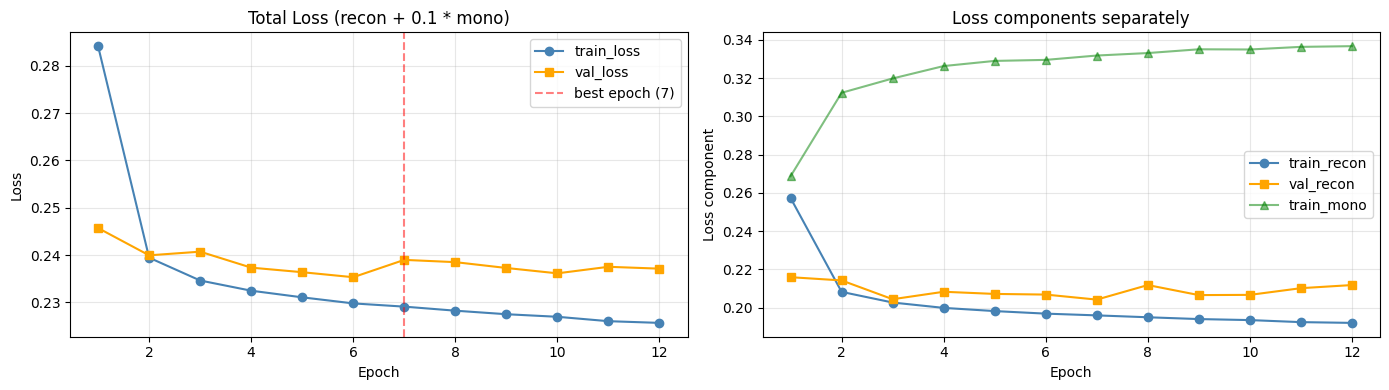


DIAGNOSTIC 2: Per-Feature MSE on Val Set

feature                      |        MSE |        MAE |   true std |   pred std
--------------------------------------------------------------------------------
  ŷ_lap_time                 |    0.04377 |    0.08844 |     0.4008 |     0.3619
  ŷ_lap_time_delta           |    0.93956 |    0.53838 |     1.4847 |     0.9979
  ŷ_tyre_life                |    0.00051 |    0.01686 |     0.1907 |     0.1898
  ŷ_position_change          |    0.03479 |    0.09864 |     0.5081 |     0.4624
  ŷ_cumulative_degradation   |    0.00218 |    0.02912 |     0.2411 |     0.2386

  Mean MSE across features:   0.20416
  This matches val_recon:     0.20416

DIAGNOSTIC 3: Predicted vs Actual Scatter (val set)


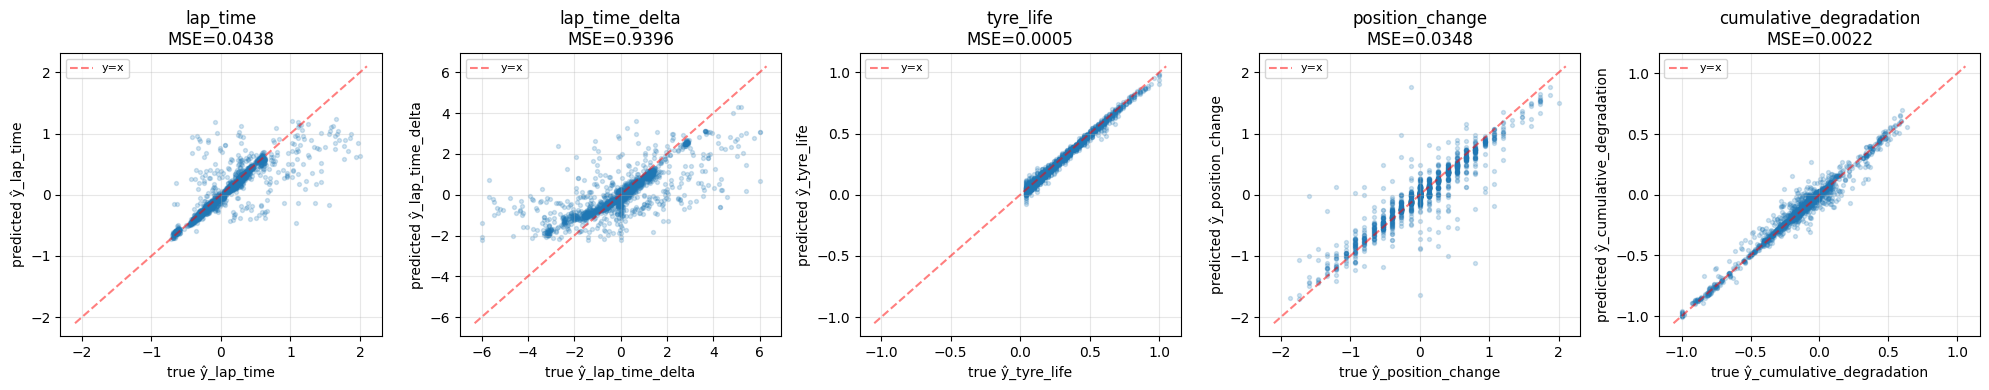


DIAGNOSTIC 4: Per-Compound MSE Breakdown

compound       |      n |   lap_time |   lt_delta |  tyre_life |    pos_chg |     cumdeg
-----------------------------------------------------------------------------------------------
  SOFT         |  1,574 |    0.05553 |    1.13342 |    0.00069 |    0.03170 |    0.00373
  MEDIUM       |  7,124 |    0.04688 |    0.95677 |    0.00055 |    0.03812 |    0.00247
  HARD         |  9,169 |    0.03571 |    0.83982 |    0.00042 |    0.02969 |    0.00149
  INTERMEDIATE |    927 |    0.07938 |    1.46701 |    0.00080 |    0.05990 |    0.00411
  WET          |     17 |    0.05549 |    0.81672 |    0.00129 |    0.30565 |    0.00473

DIAGNOSTIC 5: Strategy Mentor Effectiveness

LapTime_Delta (normalized) distribution comparison:
                     |     mean |      std |   frac < 0 |   frac > 0
      actual ŷ_delta |  -0.0127 |   1.4847 |      48.8% |      50.4%
   predicted ŷ_delta |   0.0293 |   0.9979 |      56.0% |      44.0%


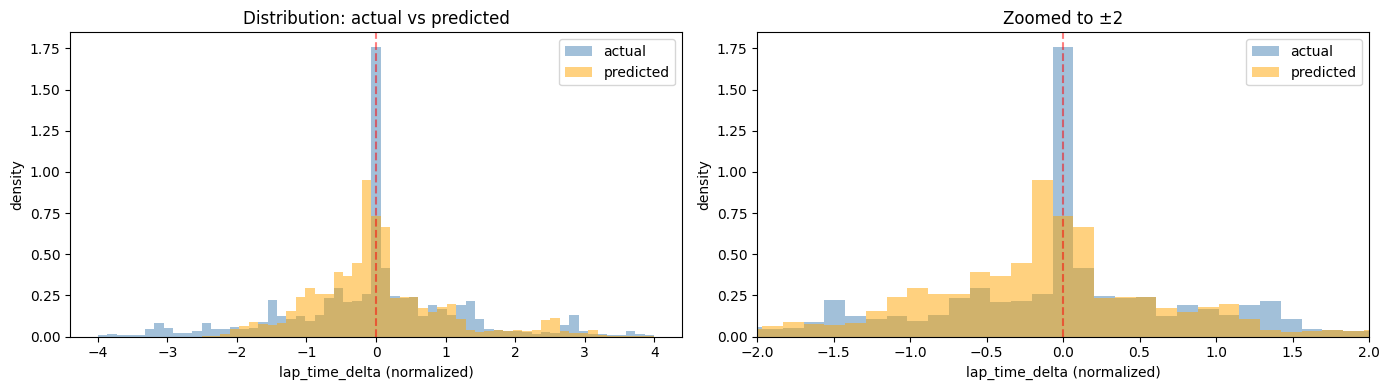


STAGE 1 DIAGNOSTIC SUMMARY
  Best val_recon:              0.20416
  Best epoch:                  7
  Train-val gap:               -0.00825
  Per-feature MSE range:       [0.00051, 0.93956]
  Predicted ŷ_delta mean:      +0.0293  (actual: -0.0127)
  Predicted ŷ_delta frac < 0:  56.0%  (actual: 48.8%)


In [10]:
# Section 10 — Stage 1 Diagnostics

print("=" * 70)
print("STAGE 1 DIAGNOSTICS")
print("=" * 70)

# Load the best checkpoint (already in memory but let's be explicit)
ckpt = torch.load(CHECKPOINTS_DIR / 'stage1_reader_imagination.pt', weights_only=False)
reader.load_state_dict(ckpt['reader_state_dict'])
imagination.load_state_dict(ckpt['imagination_state_dict'])
reader.eval()
imagination.eval()

# Generate predictions on the full validation set
TARGET_NAMES = ['lap_time', 'lap_time_delta', 'tyre_life', 'position_change', 'cumulative_degradation']

y_pred_list = []
y_true_list = []
x_list = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        z = reader(xb)
        y_pred = imagination(z, xb)
        y_pred_list.append(y_pred.cpu().numpy())
        y_true_list.append(yb.cpu().numpy())
        x_list.append(xb.cpu().numpy())

y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)
x_val_np = np.concatenate(x_list, axis=0)
print(f"Generated predictions for {len(y_pred):,} val samples")


# ── Diagnostic 1: Training curves ─────────────────────────────────
print("\n" + "=" * 70)
print("DIAGNOSTIC 1: Training Curves")
print("=" * 70)

history = ckpt['history']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: total losses
axes[0].plot(history['epoch'], history['train_loss'], 'o-', label='train_loss', color='steelblue')
axes[0].plot(history['epoch'], history['val_loss'], 's-', label='val_loss', color='orange')
axes[0].axvline(ckpt['best_epoch'], color='red', linestyle='--', alpha=0.5, label=f"best epoch ({ckpt['best_epoch']})")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Total Loss (recon + 0.1 * mono)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: recon vs mono components
axes[1].plot(history['epoch'], history['train_recon'], 'o-', label='train_recon', color='steelblue')
axes[1].plot(history['epoch'], history['val_recon'], 's-', label='val_recon', color='orange')
axes[1].plot(history['epoch'], history['train_mono'], '^-', label='train_mono', color='green', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss component')
axes[1].set_title('Loss components separately')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ── Diagnostic 2: Per-feature MSE breakdown ───────────────────────
print("\n" + "=" * 70)
print("DIAGNOSTIC 2: Per-Feature MSE on Val Set")
print("=" * 70)

per_feature_mse = ((y_pred - y_true) ** 2).mean(axis=0)
per_feature_mae = np.abs(y_pred - y_true).mean(axis=0)

print(f"\n{'feature':<28s} | {'MSE':>10s} | {'MAE':>10s} | {'true std':>10s} | {'pred std':>10s}")
print("-" * 80)
for i, name in enumerate(TARGET_NAMES):
    true_std = y_true[:, i].std()
    pred_std = y_pred[:, i].std()
    print(f"  ŷ_{name:<24s} | {per_feature_mse[i]:>10.5f} | {per_feature_mae[i]:>10.5f} | {true_std:>10.4f} | {pred_std:>10.4f}")

print(f"\n  Mean MSE across features:   {per_feature_mse.mean():.5f}")
print(f"  This matches val_recon:     {ckpt['best_val_recon']:.5f}")


# ── Diagnostic 3: Predicted vs actual scatter ─────────────────────
print("\n" + "=" * 70)
print("DIAGNOSTIC 3: Predicted vs Actual Scatter (val set)")
print("=" * 70)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
sample_idx = np.random.RandomState(SEED).choice(len(y_true), size=2000, replace=False)
for i, name in enumerate(TARGET_NAMES):
    ax = axes[i]
    ax.scatter(y_true[sample_idx, i], y_pred[sample_idx, i], alpha=0.2, s=8)
    lim = max(abs(y_true[:, i]).max(), abs(y_pred[:, i]).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', alpha=0.5, label='y=x')
    ax.set_xlabel(f'true ŷ_{name}')
    ax.set_ylabel(f'predicted ŷ_{name}')
    ax.set_title(f'{name}\nMSE={per_feature_mse[i]:.4f}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ── Diagnostic 4: Per-compound prediction quality ─────────────────
print("\n" + "=" * 70)
print("DIAGNOSTIC 4: Per-Compound MSE Breakdown")
print("=" * 70)

# Extract compound one-hot from x_val (cols 4-8 are SOFT, MEDIUM, HARD, INTER, WET)
compound_idx = np.argmax(x_val_np[:, 4:9], axis=1)
compound_names = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']

print(f"\n{'compound':<14s} | {'n':>6s} | {'lap_time':>10s} | {'lt_delta':>10s} | {'tyre_life':>10s} | {'pos_chg':>10s} | {'cumdeg':>10s}")
print("-" * 95)
for c_idx, c_name in enumerate(compound_names):
    mask = compound_idx == c_idx
    if mask.sum() < 10:
        continue
    mse_per_feature = ((y_pred[mask] - y_true[mask]) ** 2).mean(axis=0)
    print(f"  {c_name:<12s} | {mask.sum():>6,} | " + " | ".join(f"{mse_per_feature[i]:>10.5f}" for i in range(5)))


# ── Diagnostic 5: Strategy Mentor effectiveness ───────────────────
print("\n" + "=" * 70)
print("DIAGNOSTIC 5: Strategy Mentor Effectiveness")
print("=" * 70)

# Compare distribution of predicted lap_time_delta vs actual
pred_delta = y_pred[:, 1]
true_delta = y_true[:, 1]

print(f"\nLapTime_Delta (normalized) distribution comparison:")
print(f"{'':>20s} | {'mean':>8s} | {'std':>8s} | {'frac < 0':>10s} | {'frac > 0':>10s}")
print(f"  {'actual ŷ_delta':>18s} | {true_delta.mean():>8.4f} | {true_delta.std():>8.4f} | "
      f"{(true_delta < 0).mean()*100:>9.1f}% | {(true_delta > 0).mean()*100:>9.1f}%")
print(f"  {'predicted ŷ_delta':>18s} | {pred_delta.mean():>8.4f} | {pred_delta.std():>8.4f} | "
      f"{(pred_delta < 0).mean()*100:>9.1f}% | {(pred_delta > 0).mean()*100:>9.1f}%")

# Visualize: actual vs predicted distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins = np.linspace(-4, 4, 60)
axes[0].hist(true_delta, bins=bins, alpha=0.5, label='actual', color='steelblue', density=True)
axes[0].hist(pred_delta, bins=bins, alpha=0.5, label='predicted', color='orange', density=True)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('lap_time_delta (normalized)')
axes[0].set_ylabel('density')
axes[0].set_title('Distribution: actual vs predicted')
axes[0].legend()

axes[1].hist(true_delta, bins=bins, alpha=0.5, label='actual', color='steelblue', density=True)
axes[1].hist(pred_delta, bins=bins, alpha=0.5, label='predicted', color='orange', density=True)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('lap_time_delta (normalized)')
axes[1].set_ylabel('density')
axes[1].set_title('Zoomed to ±2')
axes[1].set_xlim(-2, 2)
axes[1].legend()

plt.tight_layout()
plt.show()


# Final summary
print("\n" + "=" * 70)
print("STAGE 1 DIAGNOSTIC SUMMARY")
print("=" * 70)
print(f"  Best val_recon:              {ckpt['best_val_recon']:.5f}")
print(f"  Best epoch:                  {ckpt['best_epoch']}")
print(f"  Train-val gap:               {history['train_recon'][ckpt['best_epoch']-1] - ckpt['best_val_recon']:+.5f}")
print(f"  Per-feature MSE range:       [{per_feature_mse.min():.5f}, {per_feature_mse.max():.5f}]")
print(f"  Predicted ŷ_delta mean:      {pred_delta.mean():+.4f}  (actual: {true_delta.mean():+.4f})")
print(f"  Predicted ŷ_delta frac < 0:  {(pred_delta < 0).mean()*100:.1f}%  (actual: {(true_delta < 0).mean()*100:.1f}%)")

In [11]:
# Diagnostic: How well can a simple linear model predict lap_time_delta?

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor

# Extract just the lap_time_delta target (index 1 in our 5-target vector)
y_train_delta = y_train_t[:, 1].numpy()
y_val_delta = y_val_t[:, 1].numpy()
x_train_np = x_train_t.numpy()
x_val_np_local = x_val_t.numpy()

print("=" * 70)
print("BASELINE COMPARISON — predicting lap_time_delta from x_t")
print("=" * 70)

# Baseline 1: predict the mean
mean_pred = np.full_like(y_val_delta, y_train_delta.mean())
mean_mse = ((mean_pred - y_val_delta) ** 2).mean()
print(f"\n  Baseline (predict mean):          MSE = {mean_mse:.4f}")

# Baseline 2: Linear regression
lr = LinearRegression().fit(x_train_np, y_train_delta)
lr_pred = lr.predict(x_val_np_local)
lr_mse = ((lr_pred - y_val_delta) ** 2).mean()
print(f"  Linear regression:                MSE = {lr_mse:.4f}")

# Baseline 3: Ridge regression (with regularization)
ridge = Ridge(alpha=1.0).fit(x_train_np, y_train_delta)
ridge_pred = ridge.predict(x_val_np_local)
ridge_mse = ((ridge_pred - y_val_delta) ** 2).mean()
print(f"  Ridge regression:                 MSE = {ridge_mse:.4f}")

# Baseline 4: Gradient boosting (powerful non-linear baseline)
print(f"\n  Gradient boosting (this takes ~30 sec)...")
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED)
gb.fit(x_train_np, y_train_delta)
gb_pred = gb.predict(x_val_np_local)
gb_mse = ((gb_pred - y_val_delta) ** 2).mean()
print(f"  Gradient boosting:                MSE = {gb_mse:.4f}")

# Our current PRISM model
print(f"\n  Current PRISM-F1 (from Stage 1):  MSE = 0.9396")
print(f"\n{'─' * 50}")
print(f"  Variance of the target (best possible MSE if perfectly predicted): {y_val_delta.var():.4f}")
print(f"  (Predicting the mean gives MSE = target variance)")

BASELINE COMPARISON — predicting lap_time_delta from x_t

  Baseline (predict mean):          MSE = 2.2082
  Linear regression:                MSE = 1.0577
  Ridge regression:                 MSE = 1.0577

  Gradient boosting (this takes ~30 sec)...
  Gradient boosting:                MSE = 0.8773

  Current PRISM-F1 (from Stage 1):  MSE = 0.9396

──────────────────────────────────────────────────
  Variance of the target (best possible MSE if perfectly predicted): 2.2043
  (Predicting the mean gives MSE = target variance)
